

```
# This is formatted as code
```

###Tutorial 11: Semantic Segmentation with DeepLabV3+
A pre-trained DeepLabV3 model with a ResNet-101 backbone to perform semantic segmentation:
1. Load the model from `torchvision`.
2. Preprocess an input image.
3. Visualize the output masks.

In [ ]:
import torch
import numpy as np
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load the pre-trained DeepLabV3 model using the modern weights parameter
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = models.segmentation.deeplabv3_resnet101(weights=weights).eval().to(device)

print(f"Model loaded on {device}")

Model loaded on cpu


In [ ]:
# Define the transformation for the input image
preprocess = transforms.Compose([
    transforms.Resize(520),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def segment_image(image_path):
    input_image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(input_image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_batch)['out'][0]

    output_predictions = output.argmax(0).byte().cpu().numpy()
    return input_image, output_predictions

# Helper to decode the segmentation map into colors
def decode_segmap(image, source):
    label_colors = np.array([(0, 0, 0),  # 0=background
               # 1=aeroplane, 2=bicycle, 3=bird, 4=boat, 5=bottle
               (128, 0, 0), (0, 128, 0), (128, 128, 0), (0, 0, 128), (128, 0, 128),
               # 6=bus, 7=car, 8=cat, 9=chair, 10=cow
               (0, 128, 128), (128, 128, 128), (64, 0, 0), (192, 0, 0), (64, 128, 0),
               # 11=dining table, 12=dog, 13=horse, 14=motorbike, 15=person
               (192, 128, 0), (64, 0, 128), (192, 0, 128), (64, 128, 128), (192, 128, 128),
               # 16=potted plant, 17=sheep, 18=sofa, 19=train, 20=tv/monitor
               (0, 64, 0), (128, 64, 0), (0, 192, 0), (128, 192, 0), (0, 64, 128)])

    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)

    for l in range(0, 21):
        idx = image == l
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]

    rgb = np.stack([r, g, b], axis=2)
    return rgb

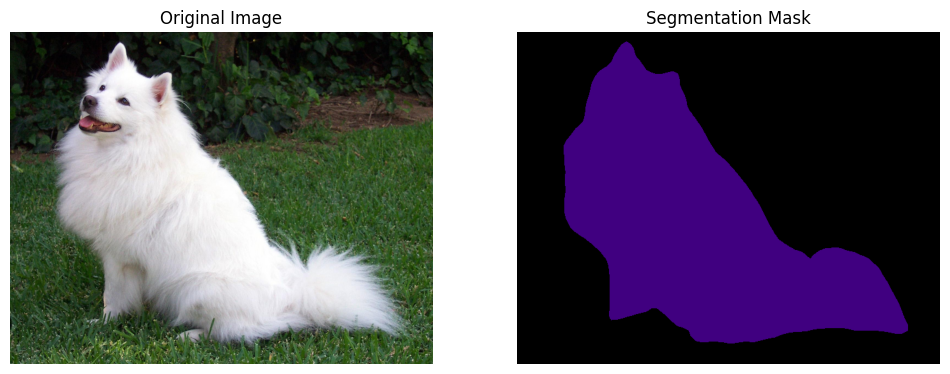

In [ ]:
# Example usage with a reliable sample image
import requests
from io import BytesIO

# Using a reliable direct link to a sample image
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
try:
    response = requests.get(url)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    img.save("test_image.jpg")

    original, mask = segment_image("test_image.jpg")
    rgb_mask = decode_segmap(mask, original)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Segmentation Mask")
    plt.imshow(rgb_mask)
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error processing image: {e}")